In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

/Users/ayushthasale07/Sarg<3/Data8/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
full = Table.read_table("nc-est2019-agesex-res.csv")

In [3]:
partial = full.select("SEX", "AGE", "POPESTIMATE2014", "POPESTIMATE2019")

In [4]:
simple = partial.relabeled("POPESTIMATE2014", "2014").relabeled("POPESTIMATE2019", "2019")
simple

SEX,AGE,2014,2019
0,0,3954787,3783052
0,1,3948891,3829599
0,2,3958711,3922044
0,3,4005928,3998665
0,4,4004032,4043323
0,5,4004576,4028281
0,6,4133372,4017227
0,7,4152666,4022319
0,8,4118349,4066194
0,9,4106068,4061874


In [5]:
below_999 = simple.where("AGE", are.below_or_equal_to(100))

overall = below_999.where("SEX", 0)

In [6]:
below_999.show(5)

SEX,AGE,2014,2019
0,0,3954787,3783052
0,1,3948891,3829599
0,2,3958711,3922044
0,3,4005928,3998665
0,4,4004032,4043323


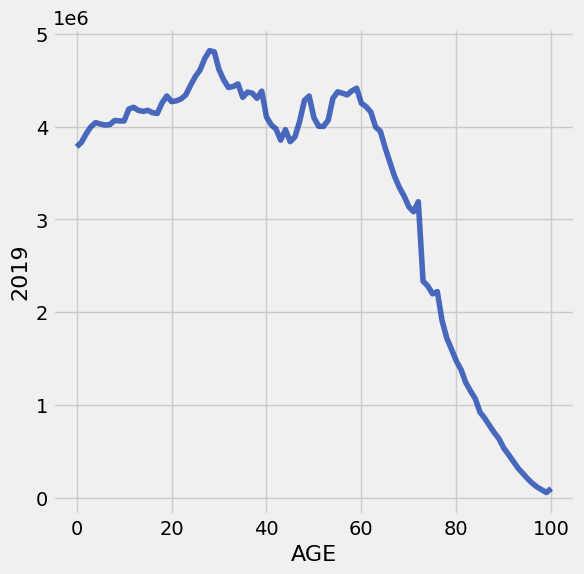

In [7]:
overall.plot("AGE", "2019")

In [8]:
males = below_999.where("SEX", 1).drop("SEX")
females = below_999.where("SEX", 2).drop("SEX")
males

AGE,2014,2019
0,2024511,1935117
1,2018511,1958585
2,2023752,2005544
3,2049250,2043010
4,2043524,2066951
5,2042790,2061200
6,2109355,2052956
7,2121426,2055735
8,2104331,2079723
9,2096379,2073148


In [9]:
pop_2019 = Table().with_columns(
    "Age", males.column("AGE"),
    "Males", males.column("2019"),
    "Females", females.column("2019")
)

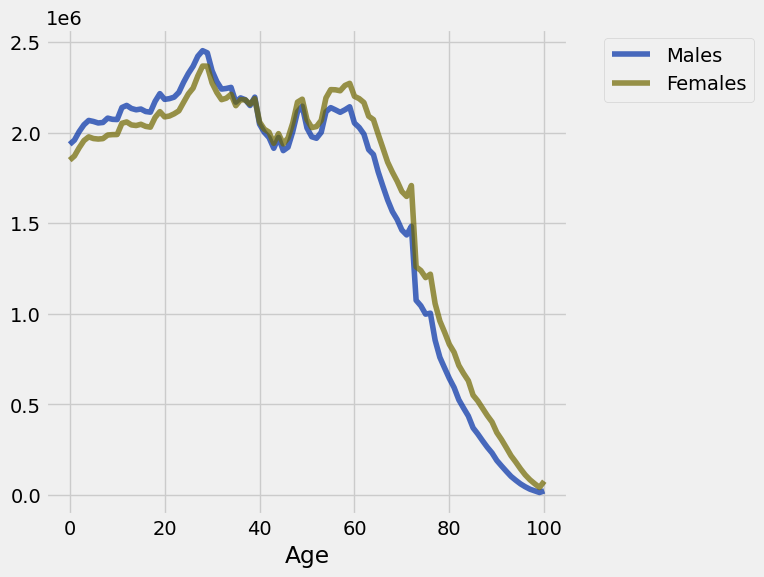

In [10]:
pop_2019.plot("Age")

In [15]:
all_age = simple.where("AGE", 999)
all_age.show(5)

SEX,AGE,2014,2019
0,999,318301008,328239523
1,999,156654424,161657324
2,999,161646584,166582199


In [19]:
perc_fem_2019 = (all_age.take(1).column("2019") / all_age.take(0).column("2019")) * 100
perc_fem_2019

array([ 49.24980469])

In [20]:
perc_ma_2019 = (all_age.take(2).column("2019") / all_age.take(0).column("2019")) * 100
perc_ma_2019

array([ 50.75019531])

In [22]:
perc_fem_2014 = (all_age.take(1).column("2014") / all_age.take(0).column("2014")) * 100
perc_fem_2014

array([ 49.21581147])

In [23]:
pop_2019

Age,Males,Females
0,1935117,1847935
1,1958585,1871014
2,2005544,1916500
3,2043010,1955655
4,2066951,1976372
5,2061200,1967081
6,2052956,1964271
7,2055735,1966584
8,2079723,1986471
9,2073148,1988726


In [27]:
total = pop_2019.column("Males") + pop_2019.column("Females")
female_percentage =( pop_2019.column("Females") / total) * 100
female_percentage

array([ 48.84772929,  48.85665575,  48.86482661,  48.90769794,
        48.87989409,  48.83177216,  48.89619133,  48.891796  ,
        48.85332574,  48.96079987,  48.98279709,  48.9638626 ,
        48.91584353,  48.91319525,  48.95759569,  48.99435008,
        49.0132324 ,  49.00202176,  48.95504446,  48.85543937,
        48.86882703,  48.87982978,  48.93202059,  48.82680386,
        48.75770556,  48.75912579,  48.69284051,  48.8521968 ,
        49.12023409,  49.23570746,  49.27026013,  49.32986637,
        49.3410954 ,  49.39558621,  49.56983336,  49.77550276,
        49.88230838,  49.98809984,  50.07964091,  49.90289454,
        50.14599374,  50.21453868,  50.37201166,  50.35627549,
        50.26558532,  50.48105622,  50.6527532 ,  50.58644103,
        50.62378332,  50.44245948,  50.55924807,  50.63152682,
        50.80644073,  50.81350976,  50.89171017,  51.13603295,
        51.27000222,  51.3678543 ,  51.52798838,  51.46621264,
        51.73196183,  51.88924675,  52.0955001 ,  52.30

(0.0, 100.0)

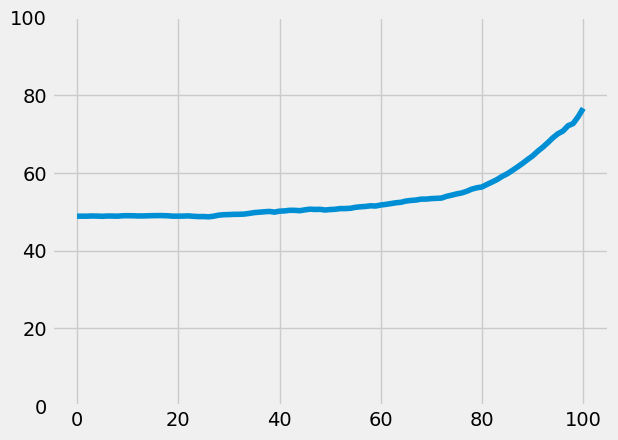

In [34]:
plots.plot(female_percentage)
plots.ylim(0, 100)